
# Category & Genre Distribution Analysis  
Using **indie.csv** and **notindie.csv**

This notebook analyzes **category and genre distributions** across Steam, Epic, and IGDB for indie vs non‑indie games.


In [2]:

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 200)

def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
    except:
        return []


## Load Data

In [3]:
indie_path = '../data/gold/indie.csv'
notindie_path = '../data/gold/notindie.csv'
indie = pd.read_csv(indie_path)
notindie = pd.read_csv(notindie_path)

# Parse category/genre list-like columns
for df in [indie, notindie]:
    for col in ["categories_steam", "categories_epic", "categories_igdb", "publishers_steam", "publishers_epic"]:
        if col in df.columns:
            df[col] = df[col].apply(parse_list)


## Combine Categories Across Platforms

In [4]:

def merge_categories(row):
    c = []
    for col in ["categories_steam","categories_epic","categories_igdb"]:
        if col in row:
            c.extend(row[col] if isinstance(row[col], list) else [])
    return [x for x in c if isinstance(x, str)]

indie["all_categories"] = indie.apply(merge_categories, axis=1)
notindie["all_categories"] = notindie.apply(merge_categories, axis=1)

indie.head(3)


,Unnamed: 0,id,steam_ID,epic_ID,igdb_ID,title,platform,developers,publishers_steam,publishers_epic,...,categories_epic,categories_igdb,effective_date_steam,effective_date_epic,effective_date_igdb,price_steam,price_epic,discount_percent_steam,discount_percent_epic,all_categories
0,1,2,2556940.0,NaN,NaN,! shakabula *,['steam'],['Skermunkel'],[Skermunkel],[],...,[],[],2023-10-13,NaN,NaN,13.88,NaN,0.0,NaN,"[Single-player, Full controller support, Steam Cloud, Family Sharing, Action, Indie, RPG, Early Access]"
1,2,3,449940.0,NaN,NaN,! that bastard is trying to steal our gold !,['steam'],['WTFOMGames'],[WTFOMGames],[],...,[],[],2016-03-03,NaN,NaN,2.77,NaN,0.0,NaN,"[Single-player, Steam Trading Cards, Partial Controller Support, Family Sharing, Action, Adventure, Casual, Indie]"
2,4,5,866510.0,NaN,NaN,!anyway!,['steam'],['EYEFRONT'],[EYEFRONT],[],...,[],[],2018-06-06,NaN,NaN,1.84,NaN,0.0,NaN,"[Single-player, Multi-player, Steam Achievements, Full controller support, Steam Trading Cards, Steam Workshop, In-App Purchases, Playable without Timed Input, Save Anytime, Steam Cloud, Stats, St..."


## Count Category Frequency

In [23]:

from collections import Counter

NOISE_KEYWORDS = ["camera", "audio", "text", "valve", "only", "steam", "cloud", "trading", "vr", "co-op", "coop", "local", "sound", "color", "difficulty", "available",
                  "achieve", "games", "controller", "pvp", "sharing", "player", "early", "remote", "shared", "Stats", "free", "custom","input","caption", "options", "indie"]

def clean_cat(cat):
    if isinstance(cat, str):
        text = cat.lower()
        return not any(key in text for key in NOISE_KEYWORDS)
    return False

# Remove any category containing 'steam'
indie_filtered_cats = [
    cat for row in indie["all_categories"] for cat in row if clean_cat(cat)
]

not_filtered_cats = [
    cat for row in notindie["all_categories"] for cat in row if clean_cat(cat)
]

# Recount after filtering
indie_cat_counts = Counter(indie_filtered_cats)
not_cat_counts   = Counter(not_filtered_cats)

# Build top-20 dataframes
indie_cat_df = pd.DataFrame(indie_cat_counts.most_common(20), columns=["Category","Count"])
not_cat_df   = pd.DataFrame(not_cat_counts.most_common(20), columns=["Category","Count"])

indie_cat_df



,Category,Count
0,Adventure,39135
1,Action,23348
2,Casual,22794
3,Strategy,18259
4,Simulation,10719
5,RPG,9606
6,Simulator,8532
7,Role-playing (RPG),6783
8,Racing,3290
9,Puzzle,3216


## Top 20 Indie Categories (Bar Plot)

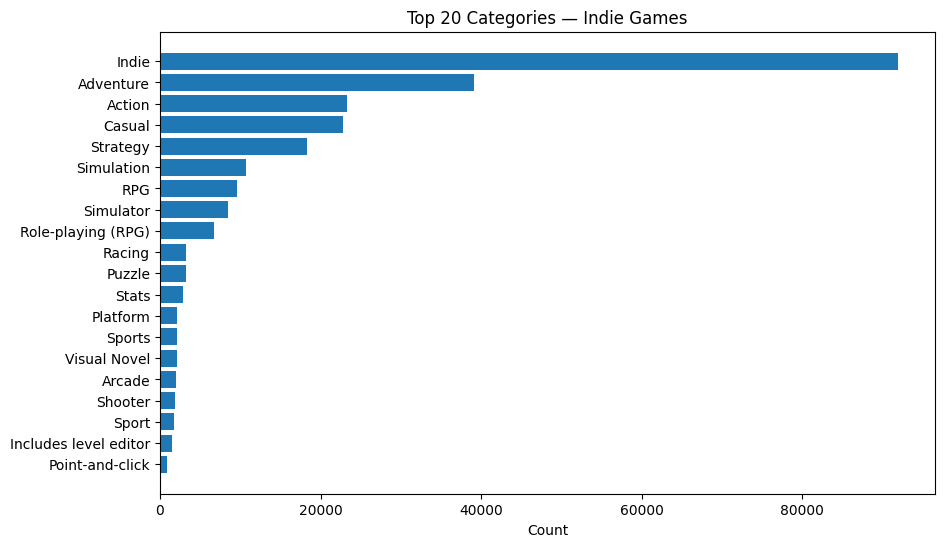

In [29]:

plt.figure(figsize=(10,6))
plt.barh(indie_cat_df["Category"], indie_cat_df["Count"])
plt.xlabel("Count")
plt.title("Top 20 Categories — Indie Games")
plt.gca().invert_yaxis()
plt.show()


## Top 20 Non‑Indie Categories (Bar Plot)

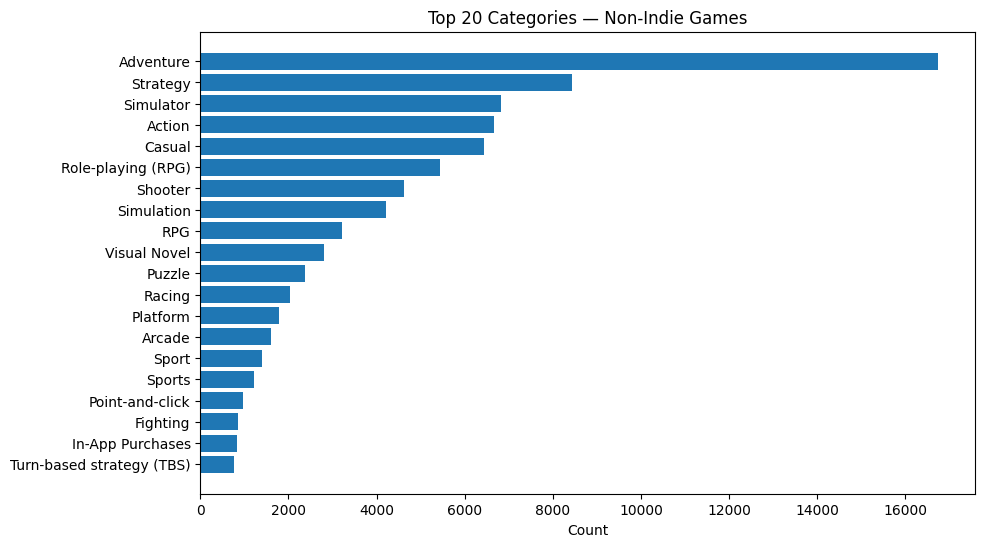

In [30]:

plt.figure(figsize=(10,6))
plt.barh(not_cat_df["Category"], not_cat_df["Count"])
plt.xlabel("Count")
plt.title("Top 20 Categories — Non‑Indie Games")
plt.gca().invert_yaxis()
plt.show()


## Compare Category Overlap

In [31]:

# overlap measure
indie_cats = set(indie_cat_counts.keys())
not_cats = set(not_cat_counts.keys())

common = indie_cats & not_cats
unique_indie = indie_cats - not_cats
unique_not = not_cats - indie_cats

summary = {
    "Total Indie Categories": len(indie_cats),
    "Total Non‑Indie Categories": len(not_cats),
    "Common Categories": len(common),
    "Indie‑Only": len(unique_indie),
    "Non‑Indie Only": len(unique_not)
}

pd.Series(summary)


Total Indie Categories        68
Total Non‑Indie Categories    65
Common Categories             65
Indie‑Only                     3
Non‑Indie Only                 0
dtype: int64

In [32]:
print(unique_indie)

{'Short', 'Indie', 'Movie'}


## Top Shared Categories Between Indie & Non‑Indie

In [33]:

shared_freq = {
    cat: indie_cat_counts[cat] + not_cat_counts[cat]
    for cat in common
}
shared_df = pd.DataFrame(sorted(shared_freq.items(), key=lambda x: -x[1])[:20],
                         columns=["Category","Total Count"])
shared_df


,Category,Total Count
0,Adventure,55884
1,Action,30012
2,Casual,29240
3,Strategy,26690
4,Simulator,15365
5,Simulation,14923
6,RPG,12830
7,Role-playing (RPG),12210
8,Shooter,6533
9,Puzzle,5587


## Shared Category Distribution (Bar Plot)

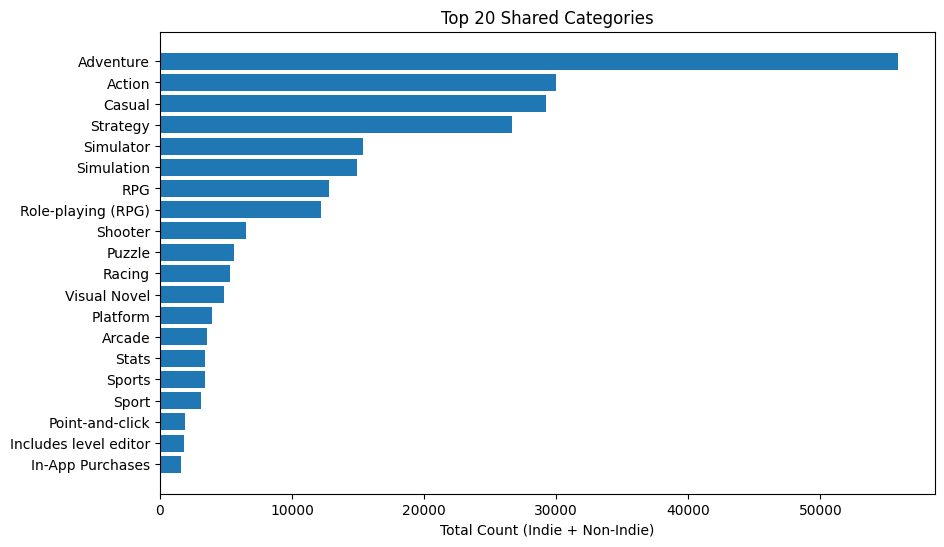

In [34]:

plt.figure(figsize=(10,6))
plt.barh(shared_df["Category"], shared_df["Total Count"])
plt.xlabel("Total Count (Indie + Non‑Indie)")
plt.title("Top 20 Shared Categories")
plt.gca().invert_yaxis()
plt.show()


In [5]:
price_cols = [c for c in indie.columns if "price" in c.lower()]
disc_cols  = [c for c in indie.columns if "discount" in c.lower()]

steam_price   = next((c for c in price_cols if "steam" in c.lower()), None)
epic_price    = next((c for c in price_cols if "epic"  in c.lower()), None)
steam_discount = next((c for c in disc_cols  if "steam" in c.lower()), None)
epic_discount  = next((c for c in disc_cols  if "epic"  in c.lower()), None)

df = indie.copy()

for col in [steam_price, epic_price, steam_discount, epic_discount]:
    if col:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalize discount 0–1 → %
for col in [steam_discount, epic_discount]:
    if col:
        mx = df[col].max(skipna=True)
        if mx <= 1:
            df[col] = df[col] * 100
        df[col] = df[col].clip(lower=0, upper=100)

df["combined_price"] = df[[steam_price, epic_price]].mean(axis=1)
df["combined_discount"] = df[[steam_discount, epic_discount]].mean(axis=1)

exploded = df.explode("all_categories")
exploded = exploded[exploded["all_categories"].apply(clean_cat)]


final = (
    exploded
    .groupby("all_categories")
    .agg(
        price_count     = ("combined_price", "count"),
        avg_price       = ("combined_price", "mean"),
        avg_discount    = ("combined_discount", "mean"),
    )
    .sort_values("avg_discount", ascending=False)
    .reset_index()
    .rename(columns={"genre_list": "genre"})
)

# Round for readability
final["avg_price"] = final["avg_price"].round(2)
final["avg_discount"] = final["avg_discount"].round(2)

display(final.head(20))

,all_categories,price_count,avg_price,avg_discount
0,Software Training,12,12.15,9.17
1,Racing,1637,9.39,7.82
2,Sports,1865,12.02,6.29
3,Simulation,9552,11.36,5.09
4,Narrated Game Menus,33,10.99,5.00
5,Save Anytime,595,24.98,4.97
6,RPG,8455,10.20,4.96
7,Utilities,48,6.84,4.94
8,Adventure,19697,8.96,4.91
9,Casual,20225,6.47,4.67


In [ ]:
final2 = (
    exploded
    .groupby("all_categories")
    .agg(
        price_count     = ("combined_price", "count"),
        avg_price       = ("combined_price", "mean"),
        avg_discount    = ("combined_discount", "mean"),
    )
    .sort_values("avg_discount", ascending=True)
    .reset_index()
    .rename(columns={"all_categories": "genre"})
)

# Round for readability
final2["avg_price"] = final2["avg_price"].round(2)
final2["avg_discount"] = final2["avg_discount"].round(2)

display(final2.head(20))

,all_categories,price_count,avg_price,avg_discount
0,Accounting,2,7.26,0.00
1,Includes Source SDK,18,9.01,0.00
2,Web Publishing,4,20.93,0.00
3,Photo Editing,11,6.48,0.00
4,Gore,154,4.78,0.91
5,Violent,241,4.86,1.33
6,Nudity,61,4.79,1.48
7,Sexual Content,52,4.86,1.73
8,Design & Illustration,25,8.02,2.40
9,Game Development,25,12.24,2.68


In [25]:
pub_cols = [c for c in indie.columns if "publisher" in c.lower()]

def merge_publishers(row):
    c = []
    for col in pub_cols:
        if col in row:
            c.extend(row[col] if isinstance(row[col], list) else [])
    return [x for x in c if isinstance(x, str)]


indie["all_publishers"] = indie.apply(merge_publishers, axis=1)



In [26]:
pairs = indie.explode("all_publishers").explode("all_categories")[
    ["all_publishers","all_categories"]
]
pairs = pairs[pairs["all_categories"].apply(clean_cat)]
pairs.head()

,all_publishers,all_categories
0,Skermunkel,Action
0,Skermunkel,RPG
0,Skermunkel,Action
0,Skermunkel,RPG
1,WTFOMGames,Action


In [27]:
# Count how many games each publisher published
pub_counts = (
    indie.explode("all_publishers")
         .dropna(subset=["all_publishers"])
         .groupby("all_publishers")
         .size()
         .sort_values(ascending=False)
)

# Filter publishers with >5 games
publishers_over_5 = pub_counts[pub_counts > 5]

In [28]:
TOP_PUBS    = 30   # adjust
TOP_GENRES  = 20   # adjust
pub_keep    = publishers_over_5.head(TOP_PUBS).index
genre_counts = pairs.groupby("all_categories").size().sort_values(ascending=False)
genre_keep   = genre_counts.head(TOP_GENRES).index

pairs_filt = pairs[pairs["all_publishers"].isin(pub_keep) & pairs["all_categories"].isin(genre_keep)]

# ---- 3) pivot and normalize *per publisher* (row-wise) to proportions ----
pivot = pd.crosstab(pairs_filt["all_publishers"], pairs_filt["all_categories"]).astype(float)
pivot = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0)  # row-normalize

# order rows/cols by total intensity to make structure clearer
row_order = pivot.sum(axis=1).sort_values(ascending=False).index
col_order = pivot.sum(axis=0).sort_values(ascending=False).index
pivot = pivot.loc[row_order, col_order]

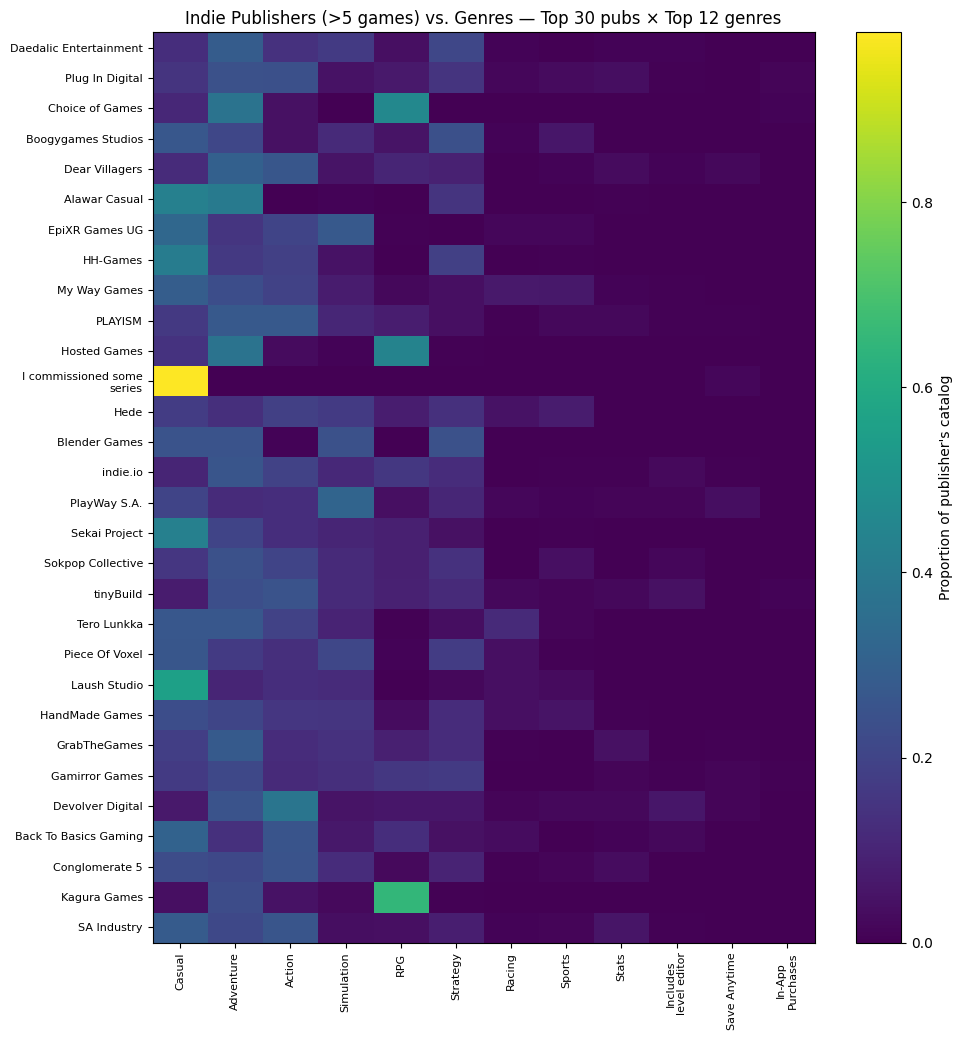

In [29]:
import textwrap
def wrap_labels(labels, width=14):
    return ["\n".join(textwrap.wrap(str(x), width)) for x in labels]

fig_h = max(6, 0.35 * len(pivot.index))   # scale figure by rows
fig_w = max(10, 0.35 * len(pivot.columns))
plt.figure(figsize=(fig_w, fig_h))

plt.imshow(pivot.values, aspect="auto", interpolation="nearest")
cb = plt.colorbar()
cb.set_label("Proportion of publisher's catalog")

plt.xticks(
    range(len(pivot.columns)),
    wrap_labels(pivot.columns, width=12),
    rotation=90, fontsize=8
)
plt.yticks(
    range(len(pivot.index)),
    wrap_labels(pivot.index, width=24),
    fontsize=8
)

plt.title(f"Indie Publishers (>5 games) vs. Genres — Top {len(pivot.index)} pubs × Top {len(pivot.columns)} genres")
plt.tight_layout()
plt.show()

In [10]:
# Publisher → set of genres
pub_genres = pairs.groupby("all_publishers")["all_categories"].apply(lambda x: sorted(set(x)))

# Count unique genres per publisher
pub_genre_counts = pub_genres.apply(len).sort_values()

# Result: publishers with the fewest genres
least_genre_publishers = pub_genre_counts[pub_genre_counts == pub_genre_counts.min()]
least_genre_publishers

all_publishers
NINJINIX                1
Pole Pig Productions    1
Polaris(붙박이별)           1
vkanio_game             1
Aldo Jeffrey            1
                       ..
饺子社                     1
Fatnicko                1
Fat Walrus Games        1
The Space               1
Ozzie Sneddon           1
Name: all_categories, Length: 1310, dtype: int64